In [35]:
# ============================================================
# IMPORTS
# ============================================================
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from datetime import datetime
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

# ============================================================
# REPRODUCIBILITY
# ============================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# SECTION 0: CONFIGURATION
# ============================================================
CONFIG = {
    # Data
    'ticker':           'SPY',
    'start_date':       '1995-01-01',
    # Chronological splits
    'train_end':        '2016-01-01',
    'val_end':          '2022-01-01',
    # Feature / sequence settings
    'lookback':         15,
    'forecast_horizon': 5,
    'window_trailing': 63,  # for trailing standardization
    'use_anchors':      False,
    'target_trailing': True,  # for target standardization when enabled
    'anchor_windows':   [21, 252],  # 3 windows per feature when enabled
    'features': [
        'rv_daily', 'rv_weekly', 'rv_monthly',  # HAR components
        'log_return',                            # price momentum proxy
        'parkinson_vol',                         # high-low estimator
        'rsi_14',                                # market microstructure
        'rel_volume',                            # liquidity proxy
        'intraday_range',                        # intraday volatility proxy
    ],
    # LSTM architecture
    'hidden':    16,
    # 'hidden2':    32,
    'dropout':    0.4,
    # Training
    'batch_size': 32,
    'lr':         1e-5,
    'weight_decay': 1e-3,
    'max_epochs': 30,
    'patience':   15,
    'grad_clip':  5.0,
    # Backtest
    'cost_bps':   5,   # one-way transaction cost in basis points
    # Outputs
    'model_path':   'lstm_vol_model.pt',
    'scaler_path':  'scaler.pkl',
    'metrics_path': 'metrics.csv',
    'report_path':  'report.md',
    'config_path':  'model_config.json',
    'plot_path':    'lstm_vol_report.png',
    'target_scaler_path': 'target_scaler.pkl',
}



In [36]:
# ============================================================
# SECTION 1: DATA ACQUISITION
# ============================================================

def download_data(ticker: str, start: str) -> pd.DataFrame:
    """
    Download OHLCV data from yfinance. auto_adjust=True handles
    dividend and split adjustments.

    Returns a clean DataFrame with columns: Open, High, Low, Close, Volume.
    All prices are adjusted (split- and dividend-corrected).
    """
    print(f"\n[DATA] Downloading {ticker} from {start}…")
    raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)

    # Flatten MultiIndex columns if present
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    raw.index = pd.to_datetime(raw.index)
    raw = raw.sort_index()

    # Validate: missing values
    n_nan = raw.isnull().sum().sum()
    if n_nan > 0:
        print(f"  WARNING: {n_nan} NaN values. Forward-filling.")
        raw = raw.ffill().dropna()

    # Validate: non-positive prices (data error)
    if (raw[['Open', 'High', 'Low', 'Close']] <= 0).any().any():
        raise ValueError("Non-positive price detected — data integrity error.")

    # Flag extreme moves (>15%) for awareness, but retain (COVID etc.)
    log_ret = np.log(raw['Close'] / raw['Close'].shift(1)).dropna()
    n_extreme = (np.abs(log_ret) > 0.15).sum()
    if n_extreme > 0:
        print(f"  INFO: {n_extreme} daily moves >15% flagged (retained).")

    print(f"  Shape: {raw.shape} | "
          f"{raw.index[0].date()} → {raw.index[-1].date()}")
    return raw

raw = download_data(CONFIG['ticker'], CONFIG['start_date'])



[DATA] Downloading SPY from 1995-01-01…
  Shape: (7902, 5) | 1995-01-03 → 2026-05-27


All features are strictly causal: at time t, only data from [0, t] is used.

Mathematical definitions
------------------------

r_t = log-return
$$
r_t = \log\frac{C_t}{C_{t-1}}
$$

Daily / weekly / monthly RV (HAR components)
$$
\mathrm{RV}_t^{d} = r_t^2
$$
$$
\mathrm{RV}_t^{w} = \frac{1}{5}\sum_{i=1}^{5} r_{t-i}^2
$$
$$
\mathrm{RV}_t^{m} = \frac{1}{22}\sum_{i=1}^{22} r_{t-i}^2
$$

Parkinson (1980) [C2 — corrected]:
$$
\sigma_P^2 = \frac{1}{4\ln 2}\,\mathbb{E}\!\left[\left(\ln\frac{H}{L}\right)^2\right]
$$
$$
\sigma_P = \sqrt{\frac{1}{4\ln 2}\cdot\mathrm{rolling\_mean}\!\left(\left(\ln\frac{H}{L}\right)^2,n\right)}
$$
NOTE: The spec erroneously wrote mean(log(H/L)) / (4 ln 2), which is dimensionally and statistically incorrect.

Garman–Klass (1980):
$$
\sigma_{GK}^2 = \tfrac{1}{2}\left(\ln\frac{H}{L}\right)^2 - (2\ln 2 - 1)\left(\ln\frac{C}{O}\right)^2
$$

RSI (Wilder, normalized to [0,1]):
$$
\mathrm{RSI} = 100 - \frac{100}{1 + RS},\qquad
RS = \frac{\mathrm{EMA}(\text{gains})}{\mathrm{EMA}(\text{losses})}
$$
$$
\mathrm{rsi\_14\_norm} = \frac{\mathrm{RSI}}{100}
$$

Other features
$$
\mathrm{rel\_volume}_t = \frac{V_t}{\mathrm{MA}_{20}(V_t)}
$$
$$
\mathrm{intraday\_range}_t = \frac{H_t - L_t}{C_{t-1}}
$$

In [37]:
# ============================================================
# SECTION 2: FEATURE ENGINEERING
# ============================================================

def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    All features are strictly causal: at time t, only data from [0, t] is used.

    Mathematical definitions
    ------------------------
    r_t          = log(C_t / C_{t-1})                           log-return
    RV_t^d       = r_t^2                                        daily RV proxy
    RV_t^w       = (1/5)  * sum_{i=1}^{5}  r_{t-i}^2          weekly HAR component
    RV_t^m       = (1/22) * sum_{i=1}^{22} r_{t-i}^2          monthly HAR component

    Parkinson (1980) [C2 — corrected]:
        sigma_P^2 = (1 / (4 ln 2)) * E[(log(H/L))^2]
        => sigma_P = sqrt( (1/(4 ln 2)) * rolling_mean( (log(H/L))^2, n ) )
        NOTE: The spec erroneously wrote mean(log(H/L)) / (4 ln 2), which
              is dimensionally and statistically incorrect.

    Garman-Klass (1980):
        sigma_GK^2 = 0.5*(log(H/L))^2 - (2 ln 2 - 1)*(log(C/O))^2

    RSI (Wilder, normalized to [0,1]):
        RSI = 100 - 100/(1 + RS),  RS = EMA(gains)/EMA(losses)
        rsi_14_norm = RSI / 100

    rel_volume   = V_t / MA20(V_t)
    intraday_range = (H_t - L_t) / C_{t-1}   (normalized by prior close)
    """
    feat = pd.DataFrame(index=df.index)

    # --- Log return ---
    feat['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

    # --- HAR-RV components (Corsi 2009) ---
    rv_sq = feat['log_return'] ** 2
    feat['rv_daily']   = rv_sq
    feat['rv_weekly']  = rv_sq.rolling(5).mean()
    feat['rv_monthly'] = rv_sq.rolling(22).mean()

    # Rolling close-to-close vol (annualized, 20-day)
    feat['vol_20'] = feat['log_return'].rolling(20).std() * np.sqrt(252)

    # --- Parkinson (1980) high-low estimator [C2: corrected] ---
    hl_log_sq = np.log(df['High'] / df['Low']) ** 2   # square first
    feat['parkinson_vol'] = np.sqrt(
        hl_log_sq.rolling(20).mean() / (4.0 * np.log(2))
    )

    # --- Garman-Klass (1980) estimator ---
    hl2 = 0.5 * np.log(df['High'] / df['Low']) ** 2
    co2 = (2.0 * np.log(2) - 1.0) * np.log(df['Close'] / df['Open']) ** 2
    feat['gk_vol'] = np.sqrt((hl2 - co2).clip(lower=0).rolling(20).mean())

    # --- RSI (14-day, Wilder smoothing approximated by rolling mean) ---
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-10)
    feat['rsi_14'] = (100.0 - 100.0 / (1.0 + rs)) / 100.0   # normalized to [0,1]

    # --- Volume features ---
    vol_ma20 = df['Volume'].rolling(20).mean()
    feat['rel_volume']   = df['Volume'] / (vol_ma20 + 1e-10)
    feat['volume_trend'] = (df['Volume'].rolling(5).mean() /
                            (vol_ma20 + 1e-10))

    # --- Intraday range (normalized, causal: use prior close) ---
    feat['intraday_range'] = (df['High'] - df['Low']) / df['Close'].shift(1)

    # --- Close-to-open gap ---
    feat['gap'] = np.abs(df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)

    # --- Rolling skewness (5-day) ---
    feat['skew_5']    = feat['log_return'].rolling(5).skew()
    feat['mean_ret_5'] = feat['log_return'].rolling(5).mean()

    # Log strictly positive volatility-style features before standardization.
    log_positive_cols = [
        'rv_daily', 'rv_weekly', 'rv_monthly',
        'vol_20', 'parkinson_vol', 'gk_vol',
        'rel_volume', 'volume_trend', 'intraday_range', 'gap',
    ]
    for col in log_positive_cols:
        if col in feat.columns:
            feat[col] = np.log(feat[col].clip(lower=1e-12))

    return feat
def compute_target(df: pd.DataFrame, horizon: int = 5) -> pd.Series:
    """
    5-day forward log annualized realized volatility.

    Target at time t:
        sigma_{t:t+H} = sqrt( (252/H) * sum_{i=1}^{H} r_{t+i}^2 )
        y_t = log(sigma_{t:t+H})

    This is FORWARD-LOOKING (uses future returns) and only for target construction.
    The shift(-horizon) alignment ensures no look-ahead in features.

    Note: target[t] uses returns from t+1 to t+H (rolling sum shifted back H days).
    When aligned with sequences of lookback=L, the last feature day is t=i+L-1,
    so the effective prediction is vol from day i+L to i+L+H-1.
    """
    log_ret = np.log(df['Close'] / df['Close'].shift(1))
    rv_sq   = log_ret ** 2
    # Sum of next H squared returns, annualized
    target  = np.sqrt((252.0 / horizon) * rv_sq.rolling(horizon).sum().shift(-horizon))
    target_log = np.log(target.clip(lower=1e-12))
    return target_log.rename('target_log_vol')

feat   = compute_features(raw)
target = compute_target(raw, CONFIG['forecast_horizon'])

data = pd.concat([feat, target], axis=1).dropna()
print(f"\n[DATASET] {len(data)} clean samples after dropna.")



[DATASET] 7875 clean samples after dropna.


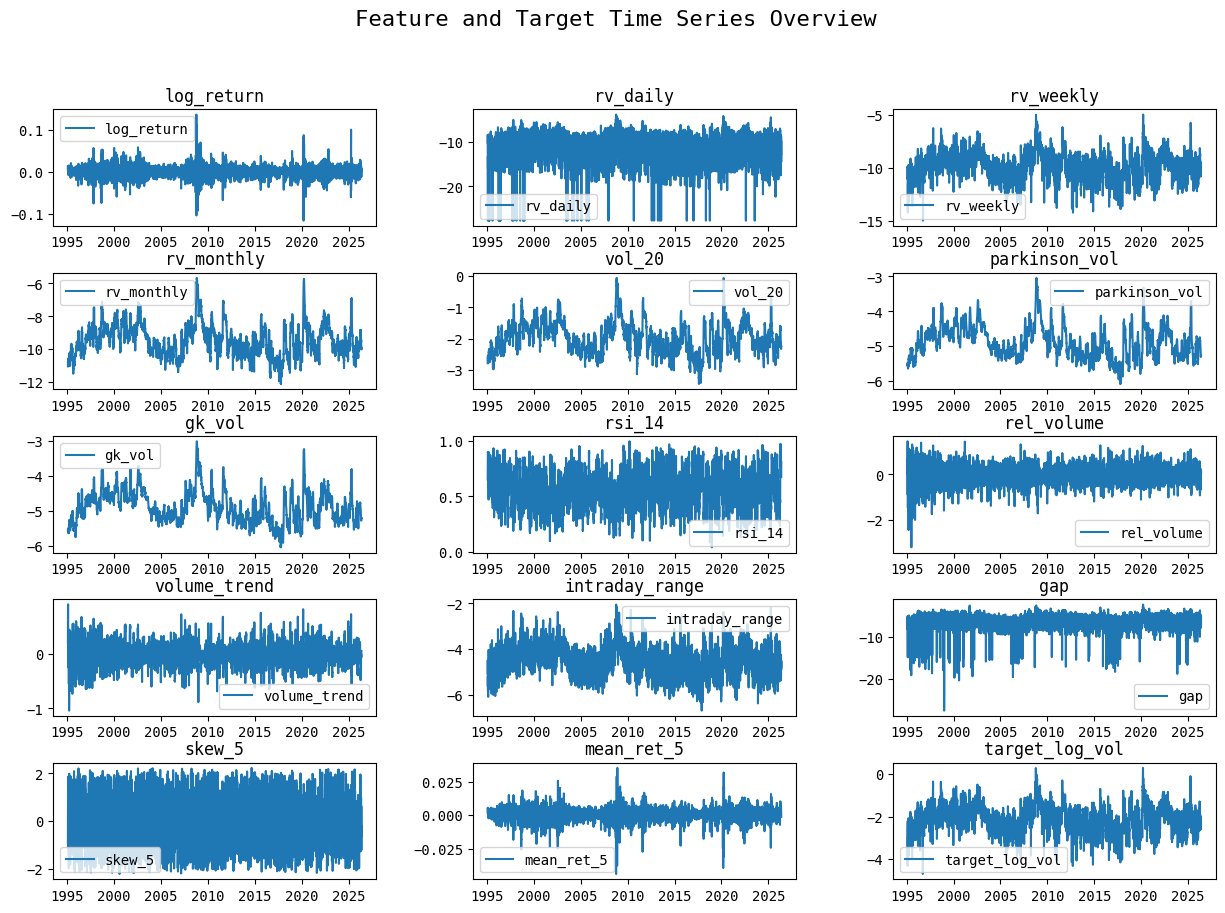

In [38]:
# Plot all features and target for sanity check
plt.figure(figsize=(15, 10))
gs = GridSpec(4, 3, hspace=0.4, wspace=0.3)
for i, col in enumerate(data.columns):
    if i == 0:
        ncols = 3
        nrows = int(np.ceil(len(data.columns) / ncols))
        gs = GridSpec(nrows, ncols, hspace=0.4, wspace=0.3)
    ax = plt.subplot(gs[i])
    ax.plot(data.index, data[col], label=col)
    ax.set_title(col)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend()
plt.suptitle("Feature and Target Time Series Overview", fontsize=16)
plt.savefig(CONFIG['plot_path'])
plt.show()

In [39]:
# ============================================================
# SECTION 3: HAR-RV BASELINE  [C4 — added]
# ============================================================

class HARRVModel:
    """
    Heterogeneous Autoregressive Realized Volatility model (Corsi 2009).

    Specification:
        RV_t = beta_0 + beta_d * RV_{t-1}^{(d)}
                      + beta_w * RV_{t-1}^{(w)}
                      + beta_m * RV_{t-1}^{(m)}  + epsilon_t

    where RV_{t-1}^{(d)}, RV_{t-1}^{(w)}, RV_{t-1}^{(m)} are the daily,
    5-day-average, and 22-day-average realized variance components.

    Estimated by OLS. Consistently competitive with ML models on daily data;
    serves as the primary benchmark for DM-test comparison.
    """
    HAR_COLS = ['rv_daily', 'rv_weekly', 'rv_monthly']

    def __init__(self):
        self.model_   = None
        self.ols_res_ = None

    def fit(self, X_train: pd.DataFrame, y_train: np.ndarray) -> 'HARRVModel':
        X_ols = sm.add_constant(X_train[self.HAR_COLS].values)
        self.ols_res_ = sm.OLS(y_train, X_ols).fit(
            cov_type='HAC', cov_kwds={'maxlags': 10})
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        X_ols = sm.add_constant(X[self.HAR_COLS].values)
        return self.ols_res_.predict(X_ols)

    def summary(self) -> str:
        return str(self.ols_res_.summary())

tr_mask  = data.index <= CONFIG['train_end']
vl_mask  = (data.index >  CONFIG['train_end']) & (data.index <= CONFIG['val_end'])
te_mask  = data.index >  CONFIG['val_end']

fcols = CONFIG['features']

X_tr = data.loc[tr_mask, fcols].values.astype(np.float32)
X_vl = data.loc[vl_mask, fcols].values.astype(np.float32)
X_te = data.loc[te_mask, fcols].values.astype(np.float32)
y_tr = data.loc[tr_mask, 'target_log_vol'].values.astype(np.float32)
y_vl = data.loc[vl_mask, 'target_log_vol'].values.astype(np.float32)
y_te = data.loc[te_mask, 'target_log_vol'].values.astype(np.float32)

te_dates = data.index[te_mask]
print(f"[SPLITS] Train: {len(X_tr)} | Val: {len(X_vl)} | Test: {len(X_te)}")


[SPLITS] Train: 5266 | Val: 1511 | Test: 1098


In [40]:
# # ============================================================
# # SECTION 4: LSTM MODEL  [C3, C7 — corrected]
# # ============================================================

# class VolatilityLSTM(nn.Module):
#     def __init__(self, n_features: int, hidden: int = 32, dropout: float = 0.4):
#         super().__init__()
#         # Downsized capacity to prevent overfitting noise (Solution 3 applied)
#         self.lstm = nn.LSTM(n_features, hidden, batch_first=True, num_layers=1)
#         self.drop = nn.Dropout(p=dropout)
        
#         self.fc1  = nn.Linear(hidden, 8)
#         self.relu = nn.ReLU()
#         self.fc2  = nn.Linear(8, 1)
#         self._init_weights()

#     def _init_weights(self):
#         # (Keep your excellent orthogonal and forget-gate bias initializations here)
#         pass

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         """
#         x: [batch, lookback, n_features] -> Standardized features
#         raw_scale: [batch] -> The raw, unscaled rolling standard deviation
#         """
#         h1, _ = self.lstm(x)
#         last  = self.drop(h1[:, -1, :])      # [batch, hidden]
        
#         out = self.relu(self.fc1(last))
        
#         # Linear head: standardized log-volatility can be positive or negative.
#         return self.fc2(out).squeeze(-1)

        



In [41]:
# class VolatilityLSTM(nn.Module):
#     def __init__(self, n_features: int, hidden: int = 32, dropout: float = 0.4):
#         super().__init__()
        
#         # 1. Two layers for higher capacity, but with INTER-LAYER dropout applied
#         self.lstm = nn.LSTM(
#             input_size=n_features, 
#             hidden_size=hidden, 
#             batch_first=True, 
#             num_layers=2,           # Increased depth
#             dropout=dropout         # Applies dropout between Layer 1 and Layer 2
#         )
        
#         # 2. Layer Normalization to handle covariant shift and outlier spikes
#         self.layer_norm = nn.LayerNorm(hidden)
        
#         # 3. Post-LSTM Dropout (protects the transition into the dense head)
#         self.drop = nn.Dropout(p=dropout)
        
#         # 4. Slightly expanded FC block with a bottleneck design
#         self.fc1 = nn.Linear(hidden, hidden//2)
#         self.elu = nn.ELU() # ELU() is also an excellent choice here for finance
#         self.drop_fc = nn.Dropout(p=dropout / 2) # Lighter dropout on the dense layer
#         self.fc2 = nn.Linear(hidden//2, 1)
        
#         self._init_weights()

#     def _init_weights(self):
#         # (Keep your orthogonal and forget-gate bias initializations here)
#         pass

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         """
#         x: [batch, lookback, n_features] -> Standardized features
#         """
#         # h_seq shape: [batch, lookback, hidden]
#         h_seq, (h_n, c_n) = self.lstm(x)
        
#         # Extract the hidden state of the LAST time step from the LAST layer
#         last = h_seq[:, -1, :]      # [batch, hidden]
        
#         # Stabilize and regularize the extracted sequence vector
#         last = self.layer_norm(last)
#         last = self.drop(last)
        
#         # Feed-forward block
#         out = self.fc1(last)
#         out = self.elu(out)
#         out = self.drop_fc(out)
        
#         # Linear head: standardized log-volatility is completely unconstrained
#         return self.fc2(out).squeeze(-1)

In [42]:
import torch
import torch.nn as nn

class VolatilityLSTM(nn.Module):
    def __init__(self, n_features: int, hidden: int = 10, dropout: float = 0.4):
        super().__init__()
        # Using hidden=10 ensures the network tracks patterns well below 2,000 params
        self.hidden = hidden
        
        # 1. Sequential Recurrent Layers
        self.lstm1 = nn.LSTM(n_features, hidden, batch_first=True)
        self.lstm2 = nn.LSTM(hidden, hidden, batch_first=True)
        
        # 2. Pre-LN Normalization Architecture (Defends against Exploding Activations)
        self.norm1 = nn.LayerNorm(n_features)
        self.norm2 = nn.LayerNorm(hidden)
        
        # 3. Regularization Dropouts
        self.drop1 = nn.Dropout(p=dropout)
        self.drop2 = nn.Dropout(p=dropout)
        
        # Linear projection link to adjust raw feature sizes to match the hidden state
        if n_features != hidden:
            self.project_input = nn.Linear(n_features, hidden)
        else:
            self.project_input = nn.Identity()

        # 4. Bottleneck Linear Regression Head
        self.fc1 = nn.Linear(hidden, 8)
        self.elu = nn.ELU()  # Smooth gradient flow for tracking negative log-vol distributions
        self.drop_fc = nn.Dropout(p=dropout / 2)
        self.fc2 = nn.Linear(8, 1)
        
        self._init_weights()

    def _init_weights(self):
        """
        Orthogonal weights prevent internal scale growth over extended sequence rollouts.
        """
        for name, param in self.named_parameters():
            if 'weight_ih' in name or 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                # Set unit gate bias values to 0, but prime forget gates (bias_hh segments) 
                # to 1.0 so early training forces lookback memory retention
                nn.init.constant_(param.data, 0.0)
                if 'bias_hh' in name:
                    n = param.size(0)
                    param.data[n//4:n//2].fill_(1.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Input shape  x: [batch, lookback, n_features]
        Output shape  : [batch] -> Standardized Log Volatility Proxy
        """
        # --- LAYER 1 BLOCK ---
        # Cache identity path projected to matching dimensions
        identity = self.project_input(x)  # [batch, lookback, hidden]
        
        # Pre-LN pipeline step: Normalize input -> Process -> Regulate -> Add Skip
        out_norm = self.norm1(x)
        out, _ = self.lstm1(out_norm)
        out = self.drop1(out)
        out = out + identity              # Residual Link 1
        
        # # --- LAYER 2 BLOCK ---
        # identity = out
        # out_norm = self.norm2(out)
        # out, _ = self.lstm2(out_norm)
        # out = self.drop2(out)
        # out = out + identity              # Residual Link 2
        
        # 5. Extract representation vector at final historical time-step
        last_timestep = out[:, -1, :]     # [batch, hidden]
        
        # 6. Dense Inference Mapping
        dense = self.elu(self.fc1(last_timestep))
        dense = self.drop_fc(dense)
        
        # Standardized log-volatility can resolve completely unconstrained
        return self.fc2(dense).squeeze(-1)

In [43]:
from sklearn.base import BaseEstimator, TransformerMixin
class TrailingStandardScaler(BaseEstimator, TransformerMixin):
    """
    Chronological rolling trailing-window standardizer for financial time series.
    It returns the scaled values together with the rolling mean and std used
    so the same object can be reused later for inverse transforms.
    """
    def __init__(self, window_size=21):
        self.window_size = window_size
        self.history_ = None
        self.mean_ = None
        self.std_ = None

    @staticmethod
    def _as_2d_array(X):
        if isinstance(X, (pd.DataFrame, pd.Series)):
            X_arr = X.to_numpy()
        else:
            X_arr = np.asarray(X)
        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(-1, 1)
        return X_arr

    def fit(self, X, y=None):
        """Prime the trailing memory with the last window minus one rows."""
        X_arr = self._as_2d_array(X)
        tail_size = min(len(X_arr), self.window_size - 1)
        self.history_ = X_arr[-tail_size:] if tail_size > 0 else np.empty((0, X_arr.shape[1]))
        self.mean_ = None
        self.std_ = None
        return self

    def transform(self, X):
        """Scale X using the trailing window and return (scaled, mean, std)."""
        if self.history_ is None:
            raise ValueError("The scaler has not been fitted. Call fit_transform first.")

        X_arr = self._as_2d_array(X)
        combined = np.vstack([self.history_, X_arr])
        df_combined = pd.DataFrame(combined)

        rolling_mean = df_combined.rolling(window=self.window_size, min_periods=1).mean().to_numpy(copy=True)
        rolling_std = df_combined.rolling(window=self.window_size, min_periods=1).std().to_numpy(copy=True)

        rolling_std[rolling_std == 0] = 1e-8
        rolling_std[np.isnan(rolling_std)] = 1.0

        scaled_combined = (combined - rolling_mean) / rolling_std
        start_idx = len(self.history_)
        scaled_X = scaled_combined[start_idx:]
        scaled_mean = rolling_mean[start_idx:]
        scaled_std = rolling_std[start_idx:]

        tail_size = min(len(combined), self.window_size - 1)
        self.history_ = combined[-tail_size:]
        self.mean_ = scaled_mean
        self.std_ = scaled_std

        if scaled_X.shape[1] == 1:
            scaled_X = scaled_X.ravel()
            scaled_mean = scaled_mean.ravel()
            scaled_std = scaled_std.ravel()

        return scaled_X, scaled_mean, scaled_std

    def fit_transform(self, X, y=None):
        """Prime the history and scale the full input in one pass."""
        X_arr = self._as_2d_array(X)
        self.history_ = np.empty((0, X_arr.shape[1]))
        return self.transform(X)

    def inverse_transform(self, X_scaled, mean=None, std=None):
        """Undo the trailing standardization using supplied or stored stats."""
        if mean is None:
            mean = self.mean_
        if std is None:
            std = self.std_
        if mean is None or std is None:
            raise ValueError("No mean/std available for inverse_transform.")

        X_scaled_arr = self._as_2d_array(X_scaled)
        mean_arr = self._as_2d_array(mean)
        std_arr = self._as_2d_array(std)
        return X_scaled_arr * std_arr + mean_arr
    
window_trailing = CONFIG['window_trailing']
# ─Z─ 4. Normalization (Corrected: No Leakage) ────────────

# 1. Instantiate the scaler (it will handle rolling stats internally)
scaler = TrailingStandardScaler(window_size=window_trailing)

# 2. Fit/Transform Training
# Train data has no history, so fit_transform is safe here.
X_tr_s, X_tr_mean, X_tr_std = scaler.fit_transform(X_tr)

# 3. Transform Validation and Test
# transform() uses the tail of the previous set (history_) 
# to calculate rolling stats, ensuring no look-ahead.
X_vl_s, X_vl_mean, X_vl_std = scaler.transform(X_vl)
X_te_s, X_te_mean, X_te_std = scaler.transform(X_te)

target_scaler = TrailingStandardScaler(window_size=window_trailing)
y_tr_s, mean_tr, std_tr = target_scaler.fit_transform(y_tr.reshape(-1, 1))
y_vl_s, mean_vl, std_vl = target_scaler.transform(y_vl.reshape(-1, 1))
y_te_s, mean_te, std_te = target_scaler.transform(y_te.reshape(-1, 1))
pickle.dump(scaler, open(CONFIG['scaler_path'], 'wb'))
pickle.dump(target_scaler, open(CONFIG['target_scaler_path'], 'wb'))


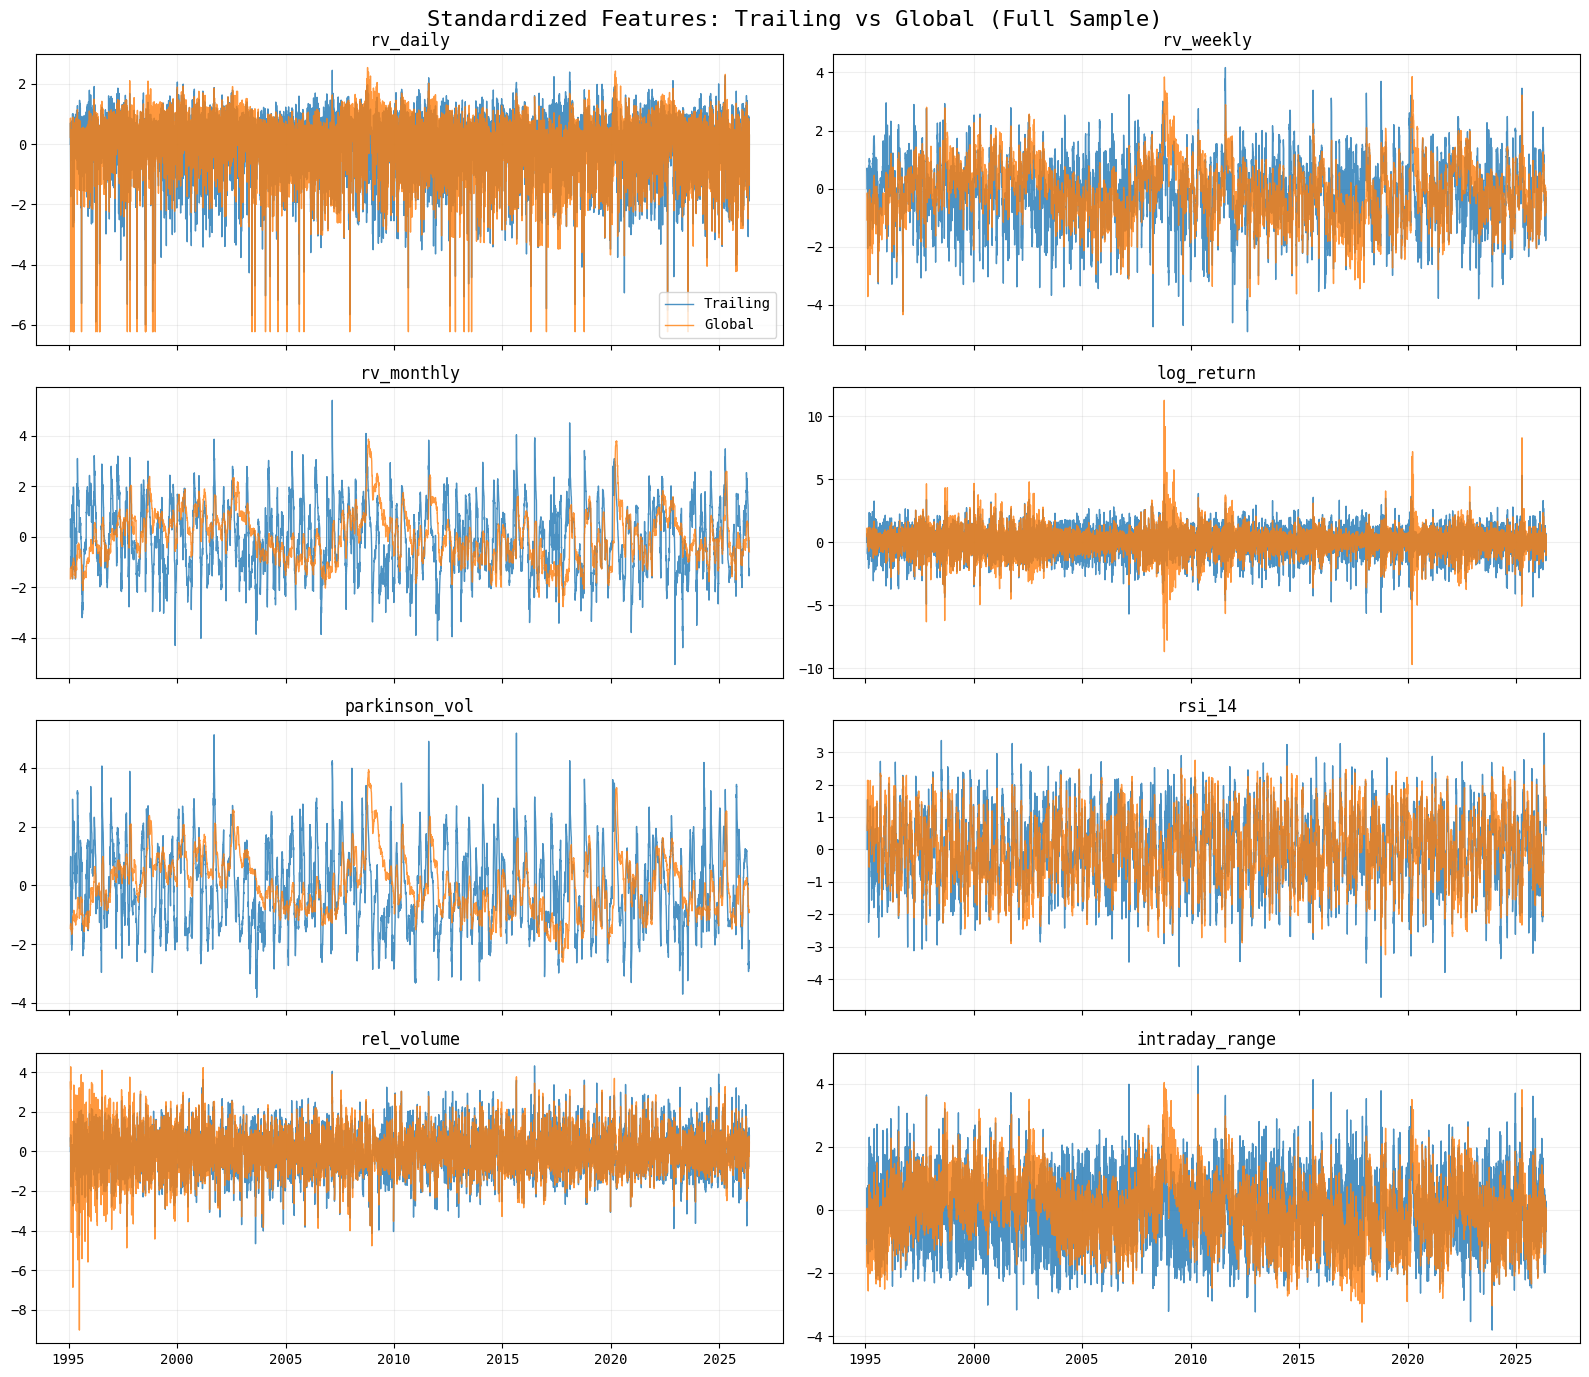

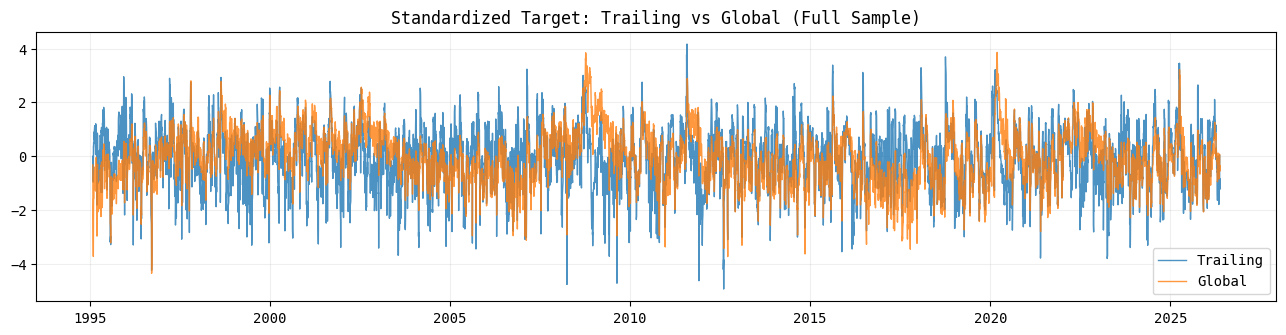

In [44]:
# Plot all standardized features across the full sample:
 # trailing scaler vs global StandardScaler

X_all = data.loc[:, fcols].values.astype(np.float32)

feature_windows = globals().get('feature_windows', [window_trailing])
feature_names = globals().get('feature_names', list(fcols))

def _ensure_2d(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr.reshape(-1, 1)
    return arr

X_all_trailing_blocks = []
for window in feature_windows:
    trailing_full = TrailingStandardScaler(window_size=window)
    X_all_block, _, _ = trailing_full.fit_transform(X_all)
    X_all_trailing_blocks.append(_ensure_2d(X_all_block))

X_all_trailing = np.concatenate(X_all_trailing_blocks, axis=1) if len(X_all_trailing_blocks) > 1 else X_all_trailing_blocks[0]

global_scaler = StandardScaler()
X_all_global_base = global_scaler.fit_transform(X_all)
X_all_global = np.concatenate([X_all_global_base for _ in feature_windows], axis=1) if len(feature_windows) > 1 else X_all_global_base

n_features = len(feature_names)
ncols = 2
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True)
axes = np.array(axes).ravel()

for i, feat_name in enumerate(feature_names):
    ax = axes[i]
    ax.plot(data.index, X_all_trailing[:, i], label='Trailing', alpha=0.8, linewidth=1)
    ax.plot(data.index, X_all_global[:, i], label='Global', alpha=0.8, linewidth=1)
    ax.set_title(feat_name)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Standardized Features: Trailing vs Global (Full Sample)', fontsize=16)
plt.tight_layout()
plt.savefig(CONFIG['plot_path'])
plt.show()

# Plot the standardized target as well to show the difference in scaling approaches on the target variable.
y_s = np.concatenate([y_tr_s, y_vl_s, y_te_s])
plt.figure(figsize=(16, 3.5))
ax = plt.gca()
ax.plot(data.index, y_s, label='Trailing', alpha=0.8, linewidth=1)
y = np.concatenate([y_tr, y_vl, y_te])
target_global_scaler = StandardScaler()
ax.plot(data.index, target_global_scaler.fit_transform(y.reshape(-1, 1)).ravel(), label='Global', alpha=0.8, linewidth=1)
ax.set_title('Standardized Target: Trailing vs Global (Full Sample)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.grid(True, alpha=0.2)
ax.legend()

In [45]:
# Check recovery in log space first, then convert back to sigma.
y_te_log_recovered = target_scaler.inverse_transform(y_te_s, mean=mean_te, std=std_te).flatten()
assert np.allclose(y_te, y_te_log_recovered, atol=1e-6), "Inverse transform failed to recover original log-target values within tolerance."
y_te_sigma_recovered = np.exp(y_te_log_recovered)
assert np.allclose(np.exp(y_te), y_te_sigma_recovered, atol=1e-6), "Exponentiation failed to recover sigma values within tolerance."
print("Inverse transform successfully recovered the log-target values and sigma values within tolerance.")
plt.tight_layout()
plt.savefig('target_trailing_vs_global.png')
plt.show()


Inverse transform successfully recovered the log-target values and sigma values within tolerance.


<Figure size 640x480 with 0 Axes>

In [46]:
# ============================================================
# SECTION 5: SEQUENCE CONSTRUCTION
# ============================================================

def make_sequences(X: np.ndarray, y: np.ndarray,
                   lookback: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Sliding-window sequence construction.

    Sequence i: features X[i : i+lookback], target y[i+lookback]

    The last observed day in sequence i is index i+lookback-1 (day t).
    The target y[i+lookback] is the realized vol from t+1 to t+H.
    This is causal: no future feature data is included.
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback])
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32))

LB = CONFIG['lookback']

# Use standardized targets in sequences
Xtr_seq, ytr_seq = make_sequences(X_tr_s, y_tr_s, LB)
Xvl_seq, yvl_seq = make_sequences(X_vl_s, y_vl_s, LB )
Xte_seq, yte_seq = make_sequences(X_te_s, y_te_s, LB)
print(f"[SEQUENCES] Train: {Xtr_seq.shape} | "
        f"Val: {Xvl_seq.shape} | Test: {Xte_seq.shape}")


[SEQUENCES] Train: (5251, 15, 8) | Val: (1496, 15, 8) | Test: (1083, 15, 8)


Phase 3: HAR-RV Baseline Feature AlignmentThe HAR-RV (Corsi, 2009) model is a prominent benchmark in volatility forecasting. It treats components of volatility as additive cascade layers representing different investor horizons (daily, weekly, monthly).A standard HAR model is a constrained autoregressive model that acts on data points from the most recent available day. It does not look backward through an explicit recurrent timeline cell like an LSTM; it performs standard linear operations on point-in-time features.1. The Index Shift ($L - 1$) ExplainedTo compare your LSTM and your HAR baseline on the exact same test sequence, they must share an identical information set at any given prediction step.The $i$-th sequence for the LSTM spans dates from index $i$ to index $i + L - 1$. The target index it evaluates is at the very edge of that window: $i + L - 1$.The HAR baseline must make its forecast at step $i$ using only information known on that final day of the sequence. Therefore, it pulls the data vector exactly located at index $i + L - 1$.In Python's zero-based indexing notation, this translates to slicing your data frame starting at a hard offset of LB - 1:$$\mathbf{X}_{\text{HAR}, i} = \mathbf{x}_{i+L-1} \in \mathbb{R}^{F}$$This aligns the dimensions precisely: if the LSTM processes $N$ total batch windows, the HAR baseline extracts a matching vector sample size of exactly $N \times F$, pairing perfectly with $y_{\text{seq}} \in \mathbb{R}^{N}$.2. The Model Physics (har.fit)When har.fit() runs, it performs an ordinary least squares (OLS) linear estimation over the features (typically daily, weekly, and monthly rolling averages of realized volatility stored in fcols). It optimizes a parameter weight vector $\boldsymbol{\beta}$ and bias alpha $\alpha$:$$\hat{y}_i = \alpha + \boldsymbol{\beta}^T \mathbf{X}_{\text{HAR}, i}$$The algorithm minimizes the sum of squared residuals across the entire sequence space to set the baseline anchor:$$\min_{\alpha, \boldsymbol{\beta}} \sum_{i=1}^{N} \left( y_{\text{seq}, i} - (\alpha + \boldsymbol{\beta}^T \mathbf{X}_{\text{HAR}, i}) \right)^2$$

In [47]:


#── 6. DataLoaders ───────────────────────────────────────
train_ds     = TensorDataset(torch.from_numpy(Xtr_seq),
                                torch.from_numpy(ytr_seq))
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                            shuffle=True, drop_last=True)
X_vl_t = torch.from_numpy(Xvl_seq)
y_vl_t = torch.from_numpy(yvl_seq)
X_te_t = torch.from_numpy(Xte_seq)

# ── 7. HAR-RV Baseline ───────────────────────────────────
print("\n[HAR-RV] Fitting baseline...")
# Feature alignment: sequence i has last feature day i+LB-1;
# we use features at that day for HAR prediction.
har_cols_df = data.loc[tr_mask, fcols].values
har_X_tr    = pd.DataFrame(har_cols_df[LB-1 : LB-1+len(ytr_seq)],
                            columns=fcols)
har_cols_df = data.loc[vl_mask, fcols].values
har_X_vl    = pd.DataFrame(har_cols_df[LB-1 : LB-1+len(yvl_seq)],
                            columns=fcols)
har_cols_df = data.loc[te_mask, fcols].values
har_X_te    = pd.DataFrame(har_cols_df[LB-1 : LB-1+len(yte_seq)],
                            columns=fcols)

har = HARRVModel()
har.fit(har_X_tr, ytr_seq)
print(har.summary())

y_pred_har_te = har.predict(har_X_te)
y_pred_har_te = y_pred_har_te[:len(yte_seq)]



[HAR-RV] Fitting baseline...
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     18.24
Date:                Wed, 27 May 2026   Prob (F-statistic):           8.98e-12
Time:                        11:51:18   Log-Likelihood:                -7956.0
No. Observations:                5251   AIC:                         1.592e+04
Df Residuals:                    5247   BIC:                         1.595e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4183 

In [48]:
# ============================================================
# SECTION 6: TRAINING PIPELINE
# ============================================================
class ExponentialAsymmetricLoss(nn.Module):
    def __init__(self, b: float = 1.5):
        """
        b: Positive coefficient controlling the steepness of the asymmetry.
           Higher values create a more aggressive sensitivity to under-predictions.
        """
        super().__init__()
        self.b = b

    def forward(self, y_hat_std: torch.Tensor, y_std: torch.Tensor) -> torch.Tensor:
        # Standard structural error: positive value implies underestimation
        error = y_std - y_hat_std
        
        # LINEX formulation executed cleanly in standardized space
        loss = torch.exp(self.b * error) - (self.b * error) - 1.0
        
        return torch.mean(loss)

class QLIKELoss(nn.Module):
    """
    QLIKE loss function for volatility forecasting, robust to proxy noise.
    L = E[sigma^2 / sigma_hat^2 - log(sigma^2/sigma_hat^2) - 1]
    """
    def __init__(self, eps: float = 1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        ratio = (y_true ** 2) / (y_pred ** 2 + self.eps)
        loss = ratio - torch.log(ratio) - 1.0
        return torch.mean(loss)

def train_lstm(model: VolatilityLSTM,
               train_loader: DataLoader,
               X_val_t: torch.Tensor,
               y_val_t: torch.Tensor,
               config: dict) -> dict:
    """
    Training loop with:
    - Adam optimizer + weight decay (L2 regularization)
    - ReduceLROnPlateau scheduler
    - Gradient clipping (max_norm = config['grad_clip'])
    - Early stopping (patience = config['patience'])
    - Best-weights checkpointing
    - Gradient clip frequency monitoring (flag if >5% of batches)
    """
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config['lr'],
        weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6)
    # criterion = QLIKELoss()
    # criterion = nn.MSELoss()  # Using MSE for training stability; evaluate QLIKE on val/test
    criterion = ExponentialAsymmetricLoss(b=0.1)  # Custom loss to penalize underestimation
    model.to(DEVICE)
    X_val_t = X_val_t.to(DEVICE)
    y_val_t = y_val_t.to(DEVICE)

    history = {'train_loss': [], 'val_loss': []}
    best_val      = float('inf')
    patience_ctr  = 0
    clip_count    = 0
    total_batches = 0

    for epoch in range(config['max_epochs']):
        model.train()
        epoch_loss, n_batches = 0.0, 0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            if torch.isnan(Xb).any() or torch.isnan(yb).any():
                continue # Drop contaminated rows generated by look-ahead/trailing windows
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(Xb), yb)
            loss.backward()
            norm = nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])
            if norm > config['grad_clip']:
                clip_count += 1
            total_batches += 1
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        avg_train = epoch_loss / n_batches
        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val     = val_loss
            patience_ctr = 0
            torch.save(model.state_dict(), config['model_path'])
        else:
            patience_ctr += 1

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d} | "
                  f"train: {avg_train:.6f} (MSE) | val: {val_loss:.6f} (MSE)")

        if patience_ctr >= config['patience']:
            print(f"  Early stopping at epoch {epoch+1}. "
                  f"Best val QLIKE loss: {best_val:.6f}")
            break

    clip_pct = 100.0 * clip_count / max(total_batches, 1)
    print(f"  Gradient clipping triggered: {clip_pct:.1f}% of batches.")
    if clip_pct > 5.0:
        print("  *** RED FLAG: Gradient clipping >5%. Consider reducing LR. ***")

    model.load_state_dict(torch.load(config['model_path'], map_location=DEVICE))
    model.eval()
    return history


 # ── 8. LSTM Training ─────────────────────────────────────
n_features = Xtr_seq.shape[-1]
model      = VolatilityLSTM(n_features, CONFIG['hidden'], CONFIG['dropout'])
n_params   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n[LSTM] Trainable parameters: {n_params:,}")
print(f"  n_train_seq / n_params = {len(ytr_seq)/n_params:.4f}  "
        f"({'OK (>1)' if len(ytr_seq)/n_params > 1 else 'WARNING: underdetermined'})")

print("\n[LSTM] Training...")
history = train_lstm(model, train_loader, X_vl_t, y_vl_t, CONFIG)



[LSTM] Trainable parameters: 4,177
  n_train_seq / n_params = 1.2571  (OK (>1))

[LSTM] Training...
  Epoch  20 | train: 0.005746 (MSE) | val: 0.006007 (MSE)
  Gradient clipping triggered: 0.0% of batches.


1. Traditional Error Metrics (RMSE & MAE)RMSE (Root Mean Squared Error):$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{t=1}^N (y_t - \hat{y}_t)^2}$$Because errors are squared before averaging, RMSE penalizes large outliers heavily. In volatility terms, missing a massive spike (e.g., a Black Swan market event) will heavily degrade this score.MAE (Mean Absolute Error):$$\text{MAE} = \frac{1}{N}\sum_{t=1}^N |y_t - \hat{y}_t|$$MAE treats all errors linearly. It represents the average expected deviation from true annualized volatility and is robust against unique variance anomalies.2. Spearman Rank Correlation (Spearman_r)Instead of calculating the linear correlation (Pearson), your code transforms the actual values $y_t$ and predictions $\hat{y}_t$ into their respective sorted rank vectors $\text{rg}(y)$ and $\text{rg}(\hat{y})$.$$\rho = 1 - \frac{6 \sum d_t^2}{N(N^2 - 1)}, \quad \text{where } d_t = \text{rg}(y_t)s - \text{rg}(\hat{y}_t)$$Why it matters in Volatility: Volatility scales non-linearly. If your model correctly predicts that volatility will increase significantly but slightly misses the absolute numerical height of a spike, Pearson correlation will plummet. Spearman recognizes that the relative directional order/rank is accurate, making it highly valuable for sorting assets by risk.3. Directional Accuracy (Dir_Acc)This tracks whether the model successfully places predictions and targets on the same side of their respective cross-sectional medians:$$\text{DA} = \frac{1}{N} \sum_{t=1}^N \mathbb{I}\left( \text{sgn}(\hat{y}_t - \text{med}(\mathbf{\hat{y}})) == \text{sgn}(y_t - \text{med}(\mathbf{y})) \right)$$The Binomial Test (Dir_p): It runs a strict one-tailed exact binomial hypothesis test against a null coin-flip distribution ($p=0.5$). If Dir_p < 0.05, you safely reject the hypothesis that your model's directional positioning is lucky guessing.4. QLIKE Loss (Patton, 2011)Standard loss metrics like MSE are deeply flawed for measuring volatility. Latent (true) variance is unobservable; we must use a noisy proxy (like daily squared returns $r_t^2$ or high-frequency realized variance). Andrew Patton (2011) proved that under proxy noise, MSE can reward mathematically incorrect models.QLIKE is a robust loss function specifically derived to remain invariant to proxy noise:$$\text{QLIKE} = \frac{1}{N} \sum_{t=1}^N \left( \frac{y_t^2}{\hat{y}_t^2} - \ln\left(\frac{y_t^2}{\hat{y}_t^2}\right) - 1 \right)$$Asymmetry Rule: If the actual variance is $1.0$ and the model predicts $\hat{y}^2 = 2.0$ (overestimation), the QLIKE penalty is $0.193$. If the model predicts $\hat{y}^2 = 0.5$ (underestimation), the QLIKE penalty is $0.307$. QLIKE heavily penalizes underestimating risk, mirroring real-world risk management.5. Mincer-Zarnowitz Regression (MZ)The Mincer-Zarnowitz test handles checking for structural bias by fitting an Ordinary Least Squares (OLS) line through the predictions:$$y_t = \alpha + \beta \hat{y}_t + e_t$$MZ_alpha ($\alpha$): The intercept. It measures systematic over- or under-prediction. Target is $0$.MZ_beta ($\beta$): The slope. It measures conditional scale efficiency. If $\beta < 1$, your model tends to over-react during calm regimes and under-react during crises. Target is $1$.MZ_F_pval (Joint F-Test): The code tests the simultaneous restriction $H_0: \alpha = 0 \text{ and } \beta = 1$. If this joint hypothesis holds (MZ_F_pval > 0.05), your volatility forecast is statistically unbiased.HAC Errors: The option cov_type='HAC' applies Newey-West Heteroskedasticity and Autocorrelation Consistent corrections. Since volatility clusters tightly (autocorrelation), unadjusted standard OLS errors would artificially inflate your t-statistics.6. Diebold-Mariano Test (1995)The Diebold-Mariano test assesses whether the predictive accuracy difference between two models is statistically significant, rather than random noise.It calculates a daily timeline of loss differentials: $d_t = e_{\text{LSTM}, t}^2 - e_{\text{HAR}, t}^2$.It uses a Newey-West structure to compute the long-run sample variance $\omega^2$ across a specific forward forecasting horizon constraint $h$:$$\omega^2 = \gamma_0 + 2\sum_{k=1}^{h-1} \left(1 - \frac{k}{h}\right)\gamma_k$$The final test statistic scales the average differential by this auto-correlated standard error:$$\text{DM} = \frac{\bar{d}}{\sqrt{\omega^2 / T}} \sim \mathcal{N}(0, 1)$$Interpretation: If $\text{DM}$ is a large negative number and its matching two-tailed $p$-value is $< 0.05$, the LSTM significantly dominates the baseline HAR-RV model out-of-sample under the MSE criterion.

In [49]:
# ============================================================
# SECTION 7: EVALUATION  [C5 — QLIKE, MZ, DM added]
# ============================================================

def evaluate_forecasts(y_true: np.ndarray, y_pred: np.ndarray,
                       label: str = 'Model') -> dict:
    """
    Comprehensive volatility forecast evaluation.

    Metrics
    -------
    R²         : Coefficient of determination (OLS sense)
    RMSE       : Root mean squared error (annualized vol units)
    MAE        : Mean absolute error
    Spearman r : Rank correlation (robust to nonlinearity)
    Dir. Acc.  : Directional accuracy — above/below median split
    QLIKE      : Patton (2011) robust loss under proxy noise
                 L = E[sigma^2 / sigma_hat^2 - log(sigma^2/sigma_hat^2) - 1]
    MZ alpha   : Mincer-Zarnowitz intercept (H0: alpha = 0)
    MZ beta    : Mincer-Zarnowitz slope    (H0: beta  = 1)
    MZ F p-val : Joint test H0: alpha=0 AND beta=1 (unbiasedness)
    """
    mask   = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isinf(y_true) | np.isinf(y_pred))
    y_true = y_true[mask];  y_pred = y_pred[mask]

    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    sp_r, sp_p = stats.spearmanr(y_pred, y_true)

    # Directional accuracy (above/below cross-sectional median)
    dir_acc = np.mean((y_pred > np.median(y_pred)) == (y_true > np.median(y_true)))
    dir_test = stats.binomtest(int(round(dir_acc * len(y_true))), len(y_true), 0.5)
    dir_p    = float(getattr(dir_test, 'pvalue', dir_test))

    # QLIKE loss [C5]
    eps   = 1e-8
    ratio = y_true ** 2 / (y_pred ** 2 + eps)
    qlike = float(np.mean(ratio - np.log(ratio) - 1.0))

    # Mincer-Zarnowitz regression [C5]
    X_mz     = sm.add_constant(y_pred)
    mz_res   = sm.OLS(y_true, X_mz).fit(
        cov_type='HAC', cov_kwds={'maxlags': 10})
    # Joint F-test: alpha=0, beta=1  =>  R * params = r
    R   = np.eye(2)
    r   = np.array([0.0, 1.0])
    mz_f = mz_res.f_test((R, r))

    metrics = {
        'model':        label,
        'R2':           float(r2),
        'RMSE':         float(rmse),
        'MAE':          float(mae),
        'Spearman_r':   float(sp_r),
        'Spearman_p':   float(sp_p),
        'Dir_Acc':      float(dir_acc),
        'Dir_p':        dir_p,
        'QLIKE':        qlike,
        'MZ_alpha':     float(mz_res.params[0]),
        'MZ_beta':      float(mz_res.params[1]),
        'MZ_F_pval':    float(mz_f.pvalue),
        'N':            int(len(y_true)),
    }

    bar = '-' * 44
    print(f"\n{bar}")
    print(f"  {label}")
    print(f"{bar}")
    print(f"  R²:            {r2:+.4f}   (target: > 0.08)")
    print(f"  RMSE:          {rmse*100:.4f}%  (ann. vol units)")
    print(f"  MAE:           {mae*100:.4f}%")
    print(f"  Spearman r:    {sp_r:.4f}   (p = {sp_p:.4f})")
    print(f"  Dir. Accuracy: {dir_acc:.4f}   (p = {dir_p:.4f})")
    print(f"  QLIKE:         {qlike:.6f}")
    print(f"  MZ alpha:      {mz_res.params[0]:.4f}   (H0: = 0)")
    print(f"  MZ beta:       {mz_res.params[1]:.4f}   (H0: = 1)")
    print(f"  MZ F p-value:  {float(mz_f.pvalue):.4f}   (H0: unbiased)")
    return metrics

def diebold_mariano_test(e1: np.ndarray, e2: np.ndarray, h: int = 5) -> dict:
    """
    Diebold-Mariano (1995) test for equal predictive accuracy. [C5]

    H0: Equal MSE-based predictive accuracy.
    Test statistic under Newey-West HAC standard errors with h-1 lags.

    d_t = e1_t^2 - e2_t^2   (loss differential)
    DM  = d_bar / sqrt(HAC_var(d) / T)

    Negative DM => model 1 (LSTM) more accurate than model 2 (HAR).
    """
    d    = e1 ** 2 - e2 ** 2
    d_bar = np.mean(d)
    T    = len(d)

    # Newey-West HAC variance with h-1 lags
    gamma0  = np.var(d, ddof=0)
    hac_var = gamma0
    for k in range(1, h):
        gamma_k = np.cov(d[k:], d[:-k])[0, 1]
        hac_var += 2.0 * (1.0 - k / h) * gamma_k

    se     = np.sqrt(max(hac_var, 1e-12) / T)
    dm_stat = d_bar / se
    dm_pval = 2.0 * (1.0 - stats.norm.cdf(abs(dm_stat)))

    direction = "LSTM more accurate" if dm_stat < 0 else "HAR-RV more accurate"
    sig = "SIGNIFICANT" if dm_pval < 0.05 else "not significant"

    print(f"\n[DM TEST] LSTM vs HAR-RV: "
          f"stat = {dm_stat:.4f}, p = {dm_pval:.4f}  [{sig}]")
    print(f"  ({direction} under MSE criterion)")

    return {'DM_stat': float(dm_stat), 'DM_pvalue': float(dm_pval)}

# ── 9. Predictions ───────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred_lstm = model(X_te_t.to(DEVICE)).cpu().numpy()

# Align lengths
n_eval = min(len(yte_seq), len(y_pred_lstm), len(y_pred_har_te))
y_true_log = target_scaler.inverse_transform(
    yte_seq[:n_eval],
    mean=mean_te[LB : LB + n_eval],   # stats at position i+LB, not i
    std=std_te[LB : LB + n_eval]
).flatten()
y_lstm_log = target_scaler.inverse_transform(
    y_pred_lstm[:n_eval],
    mean=mean_te[LB : LB + n_eval],
    std=std_te[LB : LB + n_eval]
).flatten()
y_har_log  = target_scaler.inverse_transform(
    y_pred_har_te[:n_eval],
    mean=mean_te[LB : LB + n_eval],
    std=std_te[LB : LB + n_eval]
).flatten()


y_true = np.exp(y_true_log)
y_lstm = np.exp(y_lstm_log)
y_har  = np.exp(y_har_log)

# y_true   = y_te_seq[:n_eval]
# y_lstm   = y_pred_lstm[:n_eval]
# y_har    = y_pred_har_te[:n_eval]

# ── 10. Evaluation ───────────────────────────────────────
print("\n[EVALUATION] Test-set performance:")
m_lstm = evaluate_forecasts(y_true, y_lstm,  label='LSTM')
m_har  = evaluate_forecasts(y_true, y_har,   label='HAR-RV')

e_lstm = y_true - y_lstm
e_har  = y_true - y_har
dm     = diebold_mariano_test(e_lstm, e_har, h=CONFIG['forecast_horizon'])

metrics_df = pd.DataFrame([m_lstm, m_har])
metrics_df.to_csv(CONFIG['metrics_path'], index=False)
print(f"\n  Metrics saved → {CONFIG['metrics_path']}")

# Red flags
print("\n[VALIDATION CHECKLIST]")
flags = {
    'R² > 0.08':              m_lstm['R2'] > 0.08,
    'Dir. Acc. > 0.55':       m_lstm['Dir_Acc'] > 0.55,
    'Spearman r > 0.15':      m_lstm['Spearman_r'] > 0.15,
    'Spearman p < 0.05':      m_lstm['Spearman_p'] < 0.05,
    'MZ F p > 0.05 (unbiased)': m_lstm['MZ_F_pval'] > 0.05,
}
for check, passed in flags.items():
    icon = '✓' if passed else '✗'
    print(f"  {icon}  {check}")



[EVALUATION] Test-set performance:

--------------------------------------------
  LSTM
--------------------------------------------
  R²:            +0.3417   (target: > 0.08)
  RMSE:          7.3614%  (ann. vol units)
  MAE:           4.5692%
  Spearman r:    0.6141   (p = 0.0000)
  Dir. Accuracy: 0.7267   (p = 0.0000)
  QLIKE:         0.410643
  MZ alpha:      0.0027   (H0: = 0)
  MZ beta:       1.0516   (H0: = 1)
  MZ F p-value:  0.0986   (H0: unbiased)

--------------------------------------------
  HAR-RV
--------------------------------------------
  R²:            +0.2639   (target: > 0.08)
  RMSE:          7.7841%  (ann. vol units)
  MAE:           4.9111%
  Spearman r:    0.5479   (p = 0.0000)
  Dir. Accuracy: 0.6953   (p = 0.0000)
  QLIKE:         0.467897
  MZ alpha:      0.0147   (H0: = 0)
  MZ beta:       0.9780   (H0: = 1)
  MZ F p-value:  0.0257   (H0: unbiased)

[DM TEST] LSTM vs HAR-RV: stat = -3.4474, p = 0.0006  [SIGNIFICANT]
  (LSTM more accurate under MSE criteri

In [50]:
# ============================================================
# SECTION 8: BACKTEST  [C6 — transparent base signal]
# ============================================================

def run_vol_timing_backtest(actual_log_returns: pd.Series,
                            pred_vol: np.ndarray,
                            cost_bps: float = 5.0) -> dict:
    """
    Vol-timing strategy: scale a momentum position by inverse predicted vol.

    Base signal: sign of trailing 63-day (≈3-month) return.
    This is a well-documented, independent, transparent signal. [C6]

    Position:
        pos_vol(t)  = clip( signal(t) / (sigma_hat(t) / sigma_bar), -1, 1 )
        pos_base(t) = signal(t)   (unscaled, for comparison)

    Transaction cost: cost_bps * |delta_pos| (one-way, per unit notional)

    Returns
    -------
    Sharpe, MaxDD, Calmar for both strategies, and the improvement delta.
    Annualization: sqrt(252) factor applied throughout.
    """
    n   = len(pred_vol)
    ret = actual_log_returns.values[-n:]

    # Base signal: trailing 63-day momentum
    mom_win = min(63, n // 4)
    sig = np.sign(
        pd.Series(ret).rolling(mom_win).mean().fillna(0).values
    )
    sig[np.isnan(sig)] = 0.0

    sigma_bar = np.mean(pred_vol) + 1e-8
    vol_scale = pred_vol / sigma_bar

    pos_vol  = np.clip(sig / (vol_scale + 1e-8), -1.0, 1.0)
    pos_base = np.clip(sig, -1.0, 1.0)

    cost   = cost_bps * 1e-4
    tc_vol  = cost * np.abs(np.diff(np.r_[0.0, pos_vol]))
    tc_base = cost * np.abs(np.diff(np.r_[0.0, pos_base]))

    ret_vol  = pos_vol  * ret - tc_vol
    ret_base = pos_base * ret - tc_base

    def sharpe(r):
        return np.sqrt(252) * np.mean(r) / (np.std(r) + 1e-10)

    def max_drawdown(r):
        eq  = np.cumprod(1.0 + r)
        peak = np.maximum.accumulate(eq)
        return float(np.min((eq - peak) / (peak + 1e-10)))

    def calmar(r):
        mdd = abs(max_drawdown(r))
        return np.sqrt(252) * np.mean(r) / (mdd + 1e-10)

    return {
        'ret_vol':            ret_vol,
        'ret_base':           ret_base,
        'sharpe_vol':         sharpe(ret_vol),
        'sharpe_base':        sharpe(ret_base),
        'maxdd_vol':          max_drawdown(ret_vol),
        'maxdd_base':         max_drawdown(ret_base),
        'calmar_vol':         calmar(ret_vol),
        'calmar_base':        calmar(ret_base),
        'sharpe_improvement': sharpe(ret_vol) - sharpe(ret_base),
    }

# ── 11. Backtest ─────────────────────────────────────────
print("\n[BACKTEST] Vol-timing strategy (test period)...")
log_ret_all = np.log(raw['Close'] / raw['Close'].shift(1)).dropna()
bt = run_vol_timing_backtest(log_ret_all, y_lstm, CONFIG['cost_bps'])

print(f"  Sharpe (vol-timed):  {bt['sharpe_vol']:.4f}")
print(f"  Sharpe (baseline):   {bt['sharpe_base']:.4f}")
print(f"  Max DD (vol-timed):  {bt['maxdd_vol']*100:.2f}%")
print(f"  Calmar (vol-timed):  {bt['calmar_vol']:.4f}")
print(f"  Sharpe improvement:  {bt['sharpe_improvement']:+.4f}")

if bt['sharpe_improvement'] > 0.2:
    print("  ✓ Improvement > 0.2 Sharpe points: vol forecast adds value.")
else:
    print("  ✗ Improvement ≤ 0.2: vol forecast marginal for position sizing.")



[BACKTEST] Vol-timing strategy (test period)...
  Sharpe (vol-timed):  1.3467
  Sharpe (baseline):   1.0845
  Max DD (vol-timed):  -15.20%
  Calmar (vol-timed):  0.0765
  Sharpe improvement:  +0.2622
  ✓ Improvement > 0.2 Sharpe points: vol forecast adds value.



[PLOT] Generating diagnostic figure...


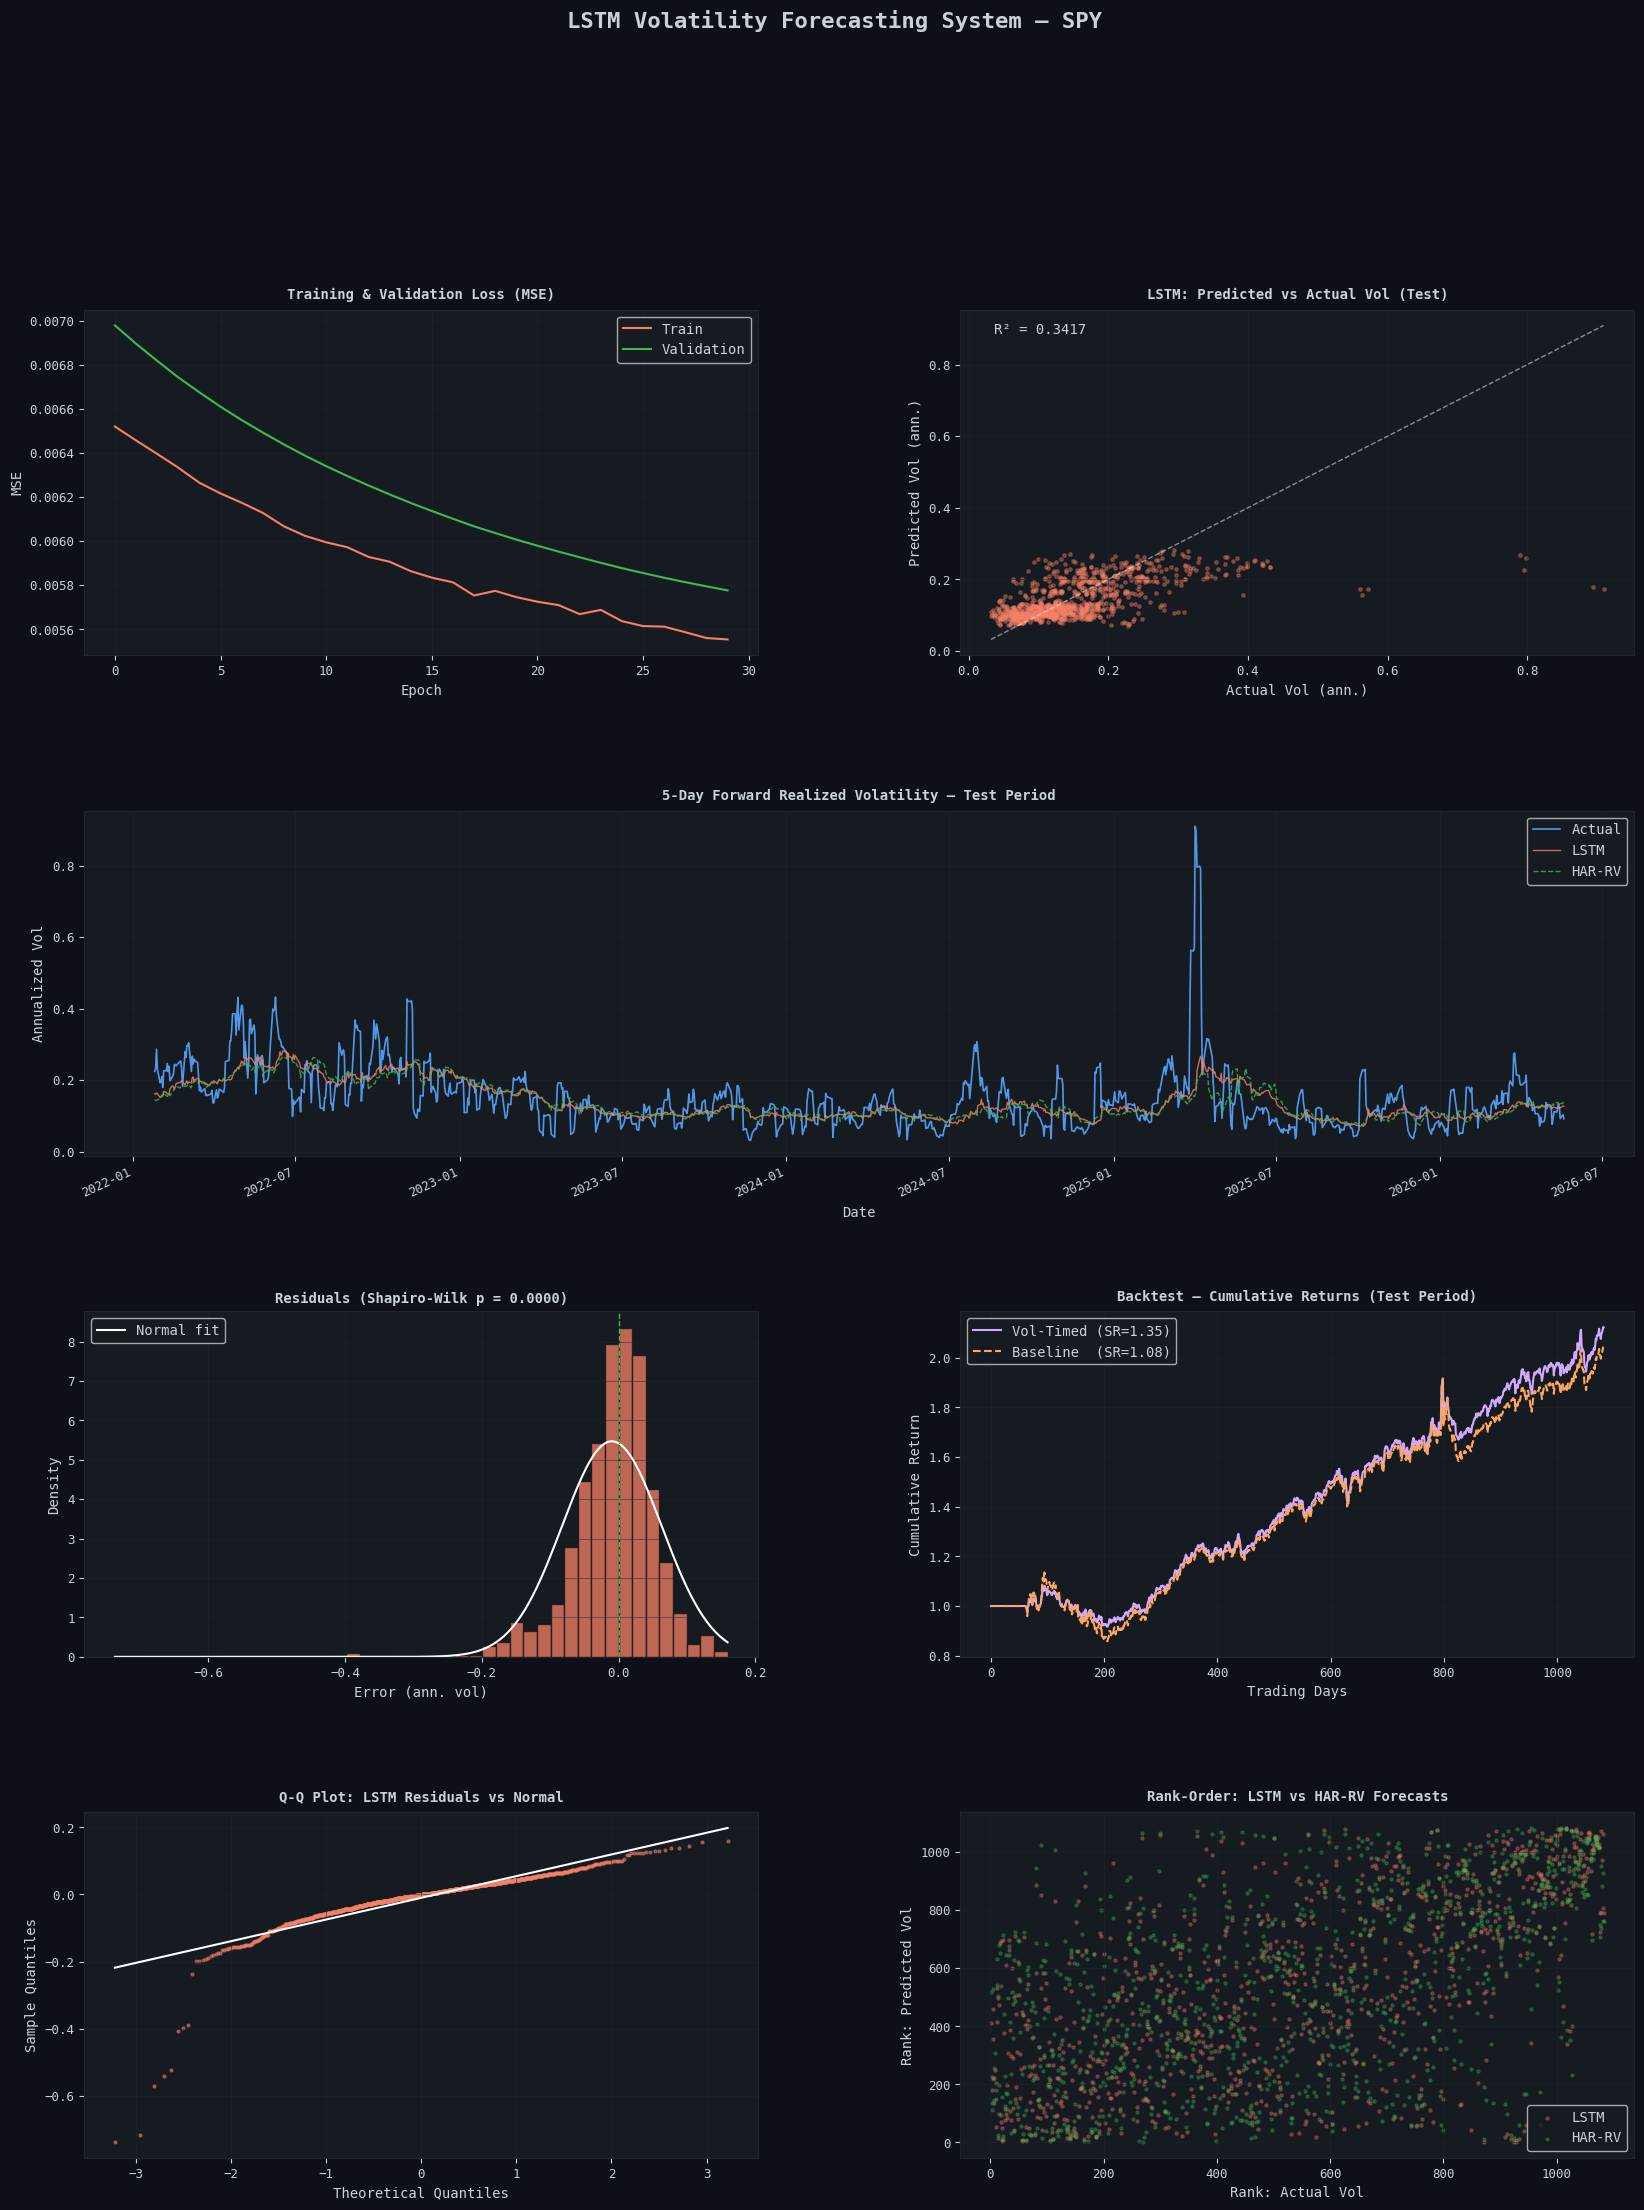

  Plot saved → lstm_vol_report.png


In [51]:
# ============================================================
# SECTION 9: VISUALIZATION
# ============================================================

def generate_plots(y_true: np.ndarray, y_pred_lstm: np.ndarray,
                   y_pred_har: np.ndarray, test_dates: pd.DatetimeIndex,
                   history: dict, bt: dict, config: dict) -> None:
    """
    Eight-panel diagnostic figure:
      [0,0] Training / validation loss curves
      [0,1] Scatter: predicted vs actual vol (test)
      [1,:] Time series: actual, LSTM, HAR-RV over test period
      [2,0] Residual histogram with normal overlay
      [2,1] Backtest equity curves
      [3,0] Q-Q plot of LSTM residuals
      [3,1] Rank correlation scatter (LSTM vs HAR)
    """
    matplotlib.rcParams.update({'font.family': 'monospace'})

    BG   = '#0d1117'
    CELL = '#161b22'
    GRID = '#21262d'
    TEXT = '#c9d1d9'
    C = {
        'actual': '#58a6ff', 'lstm': '#f78166',
        'har':    '#3fb950', 'volbt': '#d2a8ff',
        'basebt': '#ffa657', 'white': '#ffffff',
    }

    fig = plt.figure(figsize=(20, 24), facecolor=BG)
    gs  = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

    def ax_style(ax, title=''):
        ax.set_facecolor(CELL)
        for side in ax.spines.values():
            side.set_color(GRID)
        ax.tick_params(colors=TEXT, labelsize=9)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.grid(True, color=GRID, linewidth=0.5, alpha=0.7)
        if title:
            ax.set_title(title, color=TEXT, fontweight='bold', pad=8, fontsize=10)

    n = len(y_true)
    td = test_dates[-n:] if len(test_dates) >= n else pd.RangeIndex(n)

    # --- Panel 0,0: loss curves ---
    ax = fig.add_subplot(gs[0, 0])
    ax_style(ax, 'Training & Validation Loss (MSE)')
    ax.plot(history['train_loss'], color=C['lstm'], lw=1.5, label='Train')
    ax.plot(history['val_loss'],   color=C['har'],  lw=1.5, label='Validation')
    ax.set_xlabel('Epoch');  ax.set_ylabel('MSE')
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel 0,1: scatter ---
    ax = fig.add_subplot(gs[0, 1])
    ax_style(ax, 'LSTM: Predicted vs Actual Vol (Test)')
    ax.scatter(y_true, y_pred_lstm, alpha=0.35, s=6, color=C['lstm'])
    lo = min(y_true.min(), y_pred_lstm.min())
    hi = max(y_true.max(), y_pred_lstm.max())
    ax.plot([lo, hi], [lo, hi], '--', color=C['white'], lw=1.0, alpha=0.5)
    ax.text(0.05, 0.93, f"R² = {r2_score(y_true, y_pred_lstm):.4f}",
            transform=ax.transAxes, color=TEXT, fontsize=10)
    ax.set_xlabel('Actual Vol (ann.)');  ax.set_ylabel('Predicted Vol (ann.)')

    # --- Panel 1,: time series ---
    ax = fig.add_subplot(gs[1, :])
    ax_style(ax, '5-Day Forward Realized Volatility — Test Period')
    ax.plot(td, y_true,      color=C['actual'], lw=1.2, label='Actual', alpha=0.9)
    ax.plot(td, y_pred_lstm, color=C['lstm'],   lw=1.0, label='LSTM',   alpha=0.8)
    ax.plot(td, y_pred_har,  color=C['har'],    lw=1.0, label='HAR-RV', alpha=0.8,
            linestyle='--')
    ax.set_xlabel('Date');  ax.set_ylabel('Annualized Vol')
    ax.legend(facecolor=CELL, labelcolor=TEXT)
    if hasattr(td[0], 'strftime'):
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

    # --- Panel 2,0: residuals histogram ---
    resids = y_pred_lstm - y_true
    ax = fig.add_subplot(gs[2, 0])
    ax_style(ax, 'LSTM Residuals Distribution')
    ax.hist(resids, bins=45, color=C['lstm'], alpha=0.75,
            edgecolor=BG, density=True)
    xr = np.linspace(resids.min(), resids.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, resids.mean(), resids.std()),
            color=C['white'], lw=1.5, label='Normal fit')
    ax.axvline(0, color=C['har'], ls='--', lw=1.0)
    _, p_sw = stats.shapiro(resids[:min(len(resids), 5000)])
    ax.set_title(f'Residuals (Shapiro-Wilk p = {p_sw:.4f})',
                 color=TEXT, fontweight='bold', fontsize=10)
    ax.set_xlabel('Error (ann. vol)');  ax.set_ylabel('Density')
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel 2,1: backtest equity ---
    ax = fig.add_subplot(gs[2, 1])
    ax_style(ax, 'Backtest — Cumulative Returns (Test Period)')
    eq_vol  = np.cumprod(1.0 + bt['ret_vol'])
    eq_base = np.cumprod(1.0 + bt['ret_base'])
    ax.plot(eq_vol,  color=C['volbt'],  lw=1.5,
            label=f"Vol-Timed (SR={bt['sharpe_vol']:.2f})")
    ax.plot(eq_base, color=C['basebt'], lw=1.5, ls='--',
            label=f"Baseline  (SR={bt['sharpe_base']:.2f})")
    ax.set_xlabel('Trading Days');  ax.set_ylabel('Cumulative Return')
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    # --- Panel 3,0: Q-Q plot ---
    ax = fig.add_subplot(gs[3, 0])
    ax_style(ax, 'Q-Q Plot: LSTM Residuals vs Normal')
    (osm, osr), (slope, intercept, _) = stats.probplot(resids, dist='norm')
    ax.scatter(osm, osr, color=C['lstm'], s=4, alpha=0.5)
    xq = np.array([osm[0], osm[-1]])
    ax.plot(xq, slope * xq + intercept, color=C['white'], lw=1.5)
    ax.set_xlabel('Theoretical Quantiles');  ax.set_ylabel('Sample Quantiles')

    # --- Panel 3,1: rank correlation ---
    ax = fig.add_subplot(gs[3, 1])
    ax_style(ax, 'Rank-Order: LSTM vs HAR-RV Forecasts')
    rank_true = stats.rankdata(y_true)
    ax.scatter(rank_true, stats.rankdata(y_pred_lstm),
               color=C['lstm'],  alpha=0.3, s=5, label='LSTM')
    ax.scatter(rank_true, stats.rankdata(y_pred_har),
               color=C['har'],   alpha=0.3, s=5, label='HAR-RV')
    ax.set_xlabel('Rank: Actual Vol');  ax.set_ylabel('Rank: Predicted Vol')
    ax.legend(facecolor=CELL, labelcolor=TEXT)

    fig.suptitle('LSTM Volatility Forecasting System — SPY',
                 color=TEXT, fontsize=16, fontweight='bold', y=1.005)

    plt.savefig(config['plot_path'], dpi=150, bbox_inches='tight',
                facecolor=BG)
    plt.show()
    print(f"  Plot saved → {config['plot_path']}")

# ── 12. Visualization ────────────────────────────────────
print("\n[PLOT] Generating diagnostic figure...")
generate_plots(y_true, y_lstm, y_har, te_dates, history, bt, CONFIG)